In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol with an attacker, to demonstrate that the attacker can be detected.


# The flow of this notebook will be relatively the same, except we introduce the attacker's steps
# Step 1: User 1 set up and sends the qubits and bases to User 2
# Step 2: Attacker interception: the attacker intercepts the circuit before user 2 receives it
# Step 3: Attacker randomly creates bases and measures the qubits
# Step 4: Attacker retransmits the qubits as a new quantum circuit
# Step 5: User 2 receives attacker's qubits and generates bases, eventually measuring and transmitting their bases
# Step 6: User 1 receives the bases from user 2, transmits their matching bases
# Step 7: Both users create their sifted keys
# Step 8: The sifted keys will have mismatches, calculate error rate to detect attacker

In [3]:
# let user 1 generate a random sequence of bits, configurable by n
# the bits will be generated through a quantum circuit with n qubits, done with hadamard gate then measured
num_bits = 16

def measure_circuit(circuit):
    circuit_to_measure = circuit.copy()
    circuit_to_measure.measure_all()
    simulator = AerSimulator()
    compiled_circuit = transpile(circuit_to_measure, simulator)
    job = simulator.run(compiled_circuit, shots=1) # only run once, since we only need to generate the bit sequence once
    result = job.result()
    counts = result.get_counts(circuit)
    result = list(counts.keys())[0]
    return result[::-1] # reversing bit-string, since result is little-endian

def generate_bits(n):
    circuit = QuantumCircuit(n) # creating circuit with n bits
    circuit.h(range(n)) # applying hadamard gate to all qubits

    # retrieve bits through simulator
    return measure_circuit(circuit)




In [4]:
# creating user 1's original bits and bases
original_bits = generate_bits(num_bits)
user_1_bases = generate_bits(num_bits) # random bits for user 1 base, 0 being standard, 1 being diagonal

print(f"original bits from user 1: {original_bits}")
print(f"user 1 base: {user_1_bases}")

original bits from user 1: 0001111011110110
user 1 base: 0111101100001011


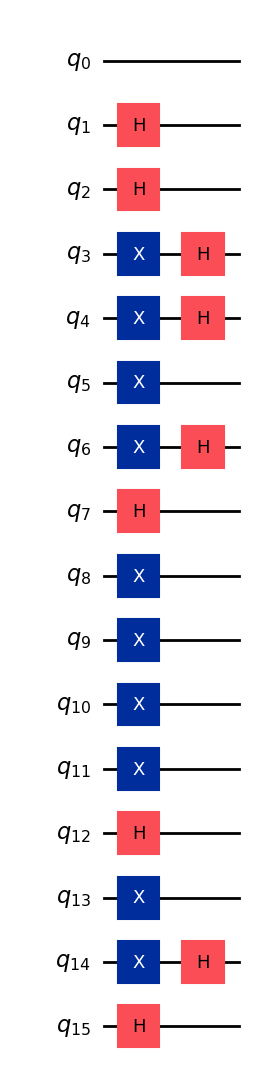

User 1's Encoded Bits Quantized:


<IPython.core.display.Latex object>

In [5]:
# convert each bit in original bits to their respective scheme
def encode_bits(bits, bases):
    circuit = QuantumCircuit(len(bits))
    for index, bit in enumerate(bits):
        if bit == '1': # regardless of the scheme, the qubit has to be flipped to 1 with X-gate
            # apply x-gate
            circuit.x(index)
        if bases[index] == '1': # if the basis is 1, user has chosen "diagonal", apply H-gate to switch to |-> or |+>
            # apply h-gate
            circuit.h(index)
    return circuit

# simulated: this entire encoded_bits is handed off to user 2, no longer accessible by user 1
encoded_bits = encode_bits(original_bits,user_1_bases)
display(encoded_bits.draw("mpl"))
quantized_encoded_bits = Statevector(encoded_bits)
print("User 1's Encoded Bits Quantized:")
display(quantized_encoded_bits.draw('latex'))

        

In [6]:
# Step 2 and 3: Attacker intercepts the encoded bits, user 2 does not receive the bits
attacker_bases = generate_bits(num_bits)
print(f"Attacker's bases: {attacker_bases}")

for index, scheme in enumerate(attacker_bases):
    if(scheme == '1'): # diagonal schemes
        encoded_bits.h(index)
quantized_attacker_bits = Statevector(encoded_bits)
print("Attacker's Encoded Bits Quantized:")
display(quantized_attacker_bits.draw('latex'))

attacker_bits = measure_circuit(encoded_bits)
print(f"Attacker's bits: {attacker_bits}")
print(f"Compared to user 1's bits: {original_bits}")

Attacker's bases: 0001011001101101
Attacker's Encoded Bits Quantized:


<IPython.core.display.Latex object>

Attacker's bits: 0111101110010100
Compared to user 1's bits: 0001111011110110


In [7]:
# Step 4: Attacker creates new quantum circuit and transmits, acting as user 1
attacker_encoded_bits = encode_bits(attacker_bits, attacker_bases)

In [8]:
# Step 5: user 2 retrieves the attacker's bits, user 2 also generates his own bases
user_2_bases = generate_bits(num_bits)
print(f"User 2's bases: {user_2_bases}")
print(f"Compared to user 1's bases: {user_1_bases}")
# user 2 now loops through each qubit and apply chosen basis (only diagonal, since the bits are already qubits, so |0> and |1> can be ignored if standard)
for index, scheme in enumerate(user_2_bases):
    if scheme == '1': # recall that scheme = 1 represents diagonal scheme
        attacker_encoded_bits.h(index)

# peek into how user 2's quantized states look like:
quantized_user_2_bits = Statevector(attacker_encoded_bits)
print("User 2's Encoded Bits Quantized:")
display(quantized_user_2_bits.draw('latex'))

# time to measure user 2s bits!
user_2_bits = measure_circuit(attacker_encoded_bits)
print(f"User 2's bits: {user_2_bits}")
print(f"Compared to user 1's bits: {original_bits}")


User 2's bases: 0000010100000100
Compared to user 1's bases: 0111101100001011
User 2's Encoded Bits Quantized:


<IPython.core.display.Latex object>

User 2's bits: 0110100110011101
Compared to user 1's bits: 0001111011110110


In [ ]:
# Step 6: User 2 transmits their bases to user 1, check matching bases
matching_indexes = []
user_1_matching_bits = ""
for index, base in enumerate(user_2_bases):
    if base == user_1_bases[index]:
        # save the bit and index in an array
        matching_indexes.append(index)
        user_1_matching_bits += original_bits[index]

print(f"Matching indexes found by user 1: {matching_indexes}")
print("Sending matching indexes to user 2")
# user 1 will advertise matching_indexes to user 2

# user 2 receives matching indexes and does the same to retrieve matching_bits
print("User 2 retrieved matching indexes")
user_2_matching_bits = ""
for index in matching_indexes:
    user_2_matching_bits += user_2_bits[index]

# Step 7: creating the sifted keys
print(f"User 1's matching bits: {user_1_matching_bits}")
print(f"User 2's matching bits: {user_2_matching_bits}")

if user_1_matching_bits == user_2_matching_bits:
    print("Both bits (keys) match!")
else:
    # Step 8: check error rate!
    print("Keys not matching, attacker detected!")
    mismatch_count = 0
    for index, bit in enumerate(user_1_matching_bits):
        if bit != user_2_matching_bits[index]:
            mismatch_count+=1
    print(f"Number of mismatched bits: {mismatch_count}")



Matching indexes found by user 1: [0, 7, 8, 9, 10, 11]
Sending matching indexes to user 2
User 2 retrieved matching indexes
User 1's matching bits: 001111
User 2's matching bits: 011001
Keys not matching, attacker detected!
Number of mismatched bits: 3


: 